<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/main/Bildextraktion_Fr%C3%BCchte_aller_Bilder_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laden der Daten und vorbereiten**

In [36]:
# BLOCK 1 — Drive mount + lokale Arbeitskopie (idempotent)
# Zweck: Drive einbinden und die komplette Baumstruktur einmalig nach /content kopieren.
# Vorteil: Training läuft lokal (schneller/stabiler). Bei erneutem "Run all" wird NICHT erneut kopiert.

from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

local_base = Path("/content/fruits_baum")
drive_base = Path("/content/drive/MyDrive/fruits_baum")

if not local_base.exists():
    print("🔁 Erstelle lokale Arbeitskopie aus Google Drive …")
    !cp -r "{drive_base}" "/content/"
else:
    print("✅ Lokale Arbeitskopie existiert bereits – überspringe Kopieren.")

print("📁 Lokale Struktur:")
!ls "/content/fruits_baum"


Mounted at /content/drive
✅ Lokale Arbeitskopie existiert bereits – überspringe Kopieren.
📁 Lokale Struktur:
test  train


In [37]:
# BLOCK 2 — Train-Pfad prüfen + Klassen anzeigen
# Zweck: Sicherstellen, dass die lokale Baumstruktur vorhanden ist und welche Klassen (Unterordner) existieren.

train_path = "/content/fruits_baum/train"
print("Train-Pfad:", train_path)
print("Existiert:", os.path.exists(train_path))

print("Klassenordner in train:")
!ls "$train_path"


Train-Pfad: /content/fruits_baum/train
Existiert: True
Klassenordner in train:
avo_bio     banane_extra   citron_bio	  mango_extra	süssK_bio
avo_normal  banane_normal  citron_normal  mango_normal	süssK_normal


In [38]:
# BLOCK 3 — OPTIONAL: Echten Testset-Ordner erstellen (idempotent, läuft nur einmal)
# Zweck: Lehrer-konform ein separates Testset erzeugen (20% pro Klasse).
# Wichtig: Dieser Block verändert NICHT train/, sondern kopiert Testbilder nach test/.
# Bei erneutem "Run all": Wenn test/ existiert und nicht leer ist, wird der Split übersprungen.

import random, shutil
from pathlib import Path

base = Path("/content/fruits_baum")
train_dir = base / "train"
test_dir  = base / "test"

if test_dir.exists() and any(test_dir.iterdir()):
    print("✅ Testset existiert bereits – kein erneuter Split.")
else:
    print("🔁 Erstelle Testset aus Trainingsdaten …")
    test_dir.mkdir(exist_ok=True)

    random.seed(42)
    test_ratio = 0.2

    for cls_dir in sorted([p for p in train_dir.iterdir() if p.is_dir()]):
        cls_name = cls_dir.name
        (test_dir / cls_name).mkdir(parents=True, exist_ok=True)

        files = [f for f in cls_dir.glob("*") if f.is_file()]
        random.shuffle(files)

        if not files:
            continue

        n_test = max(1, int(len(files) * test_ratio))
        for f in files[:n_test]:
            shutil.copy2(f, test_dir / cls_name / f.name)

    print("✅ Testset erfolgreich erstellt.")

print("📁 Test-Ordner (Klassen):")
if test_dir.exists():
    !ls "/content/fruits_baum/test"
else:
    print("Kein Test-Ordner vorhanden.")


✅ Testset existiert bereits – kein erneuter Split.
📁 Test-Ordner (Klassen):
avo_bio     banane_extra   citron_bio	  mango_extra	süssK_bio
avo_normal  banane_normal  citron_normal  mango_normal	süssK_normal


In [39]:
# BLOCK 4 — Train/Validation Dataset erstellen (aus lokalem train/)
# Zweck: Wie beim Lehrer: train/ wird in training+validation gesplittet (80/20) mit fixem Seed.
# Hinweis: image_size ist bewusst an dein Datenset angepasst (hier 128x128). Wenn du willst: 64x64.

import tensorflow as tf

Training_Baumstrukturpfad = "/content/fruits_baum/train"

validation_split = 0.2
image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    Training_Baumstrukturpfad,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    Training_Baumstrukturpfad,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Klassen (alphabetisch, wichtig für Label-Index):", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 194 files belonging to 10 classes.
Using 156 files for training.
Found 194 files belonging to 10 classes.
Using 38 files for validation.
Klassen (alphabetisch, wichtig für Label-Index): ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


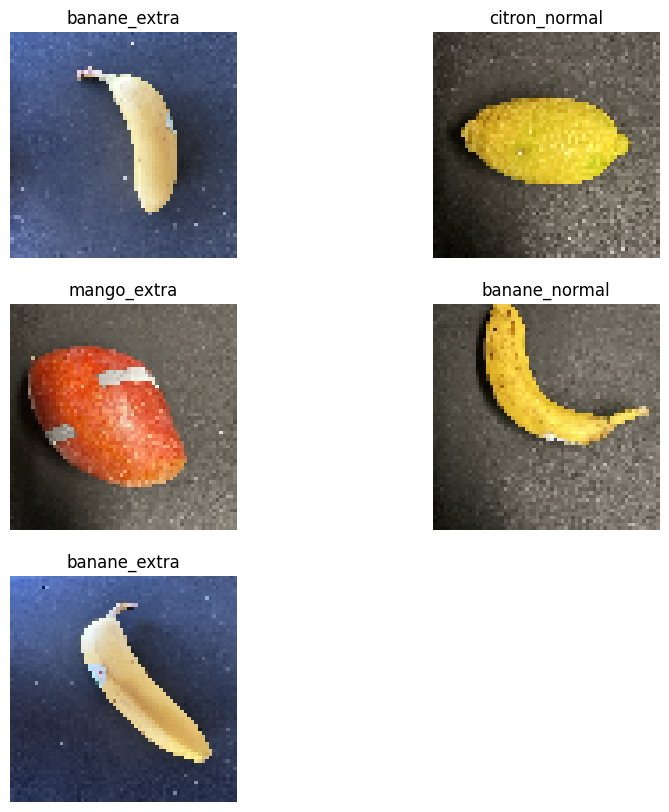

In [40]:
# BLOCK 5 — Sichtprüfung: ein paar Trainingsbilder anzeigen
# Zweck: Quick sanity check: Labels stimmen, Bildinhalt erkennbar, Auflösung passt.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [41]:
# BLOCK 6 — Modell definieren (Functional API) mit DEINEN ursprünglichen Parametern
# Zweck: CNN-Architektur genau so aufbauen wie in deinem Notebook (Conv: 64→32→16, Dense: 128→64).
# Hinweis: color_image_size basiert auf image_size, das du weiter oben gesetzt hast (z.B. 128x128).

from tensorflow.keras import layers, models
import tensorflow as tf

num_classes = len(class_names)          # Anzahl Zielklassen
color_image_size = (*image_size, 3)     # Eingabegröße inkl. 3 RGB-Kanäle

def make_model():
    # Eingabe-Layer (z.B. 64x64x3, abhängig von image_size)
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    # Normalisierung der Pixelwerte auf [0,1]
    x = layers.Rescaling(1./255)(img_inputs)

    # Datenaugmentation: zufälliges Spiegeln und Drehen
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)

    # 1. Convolutional Block (erkennt einfache Muster)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # 2. Convolutional Block (erkennt komplexere Strukturen)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # 3. Convolutional Block (noch abstraktere Features)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Übergang zu Dense Layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    # Ausgabeschicht: Softmax für Wahrscheinlichkeitsverteilung
    outputs = layers.Dense(num_classes, activation='softmax', name='Ausgabe')(x)

    # Modell definieren
    model = tf.keras.Model(inputs=img_inputs, outputs=outputs, name='FruitClassifier')
    return model

# Modell erstellen und anzeigen
model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ausgabe (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,986 (644.48 KB)

 Trainable params: 164,986 (644.48 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# BLOCK 7 — Modell kompilieren + Training mit EarlyStopping
# Zweck: Training starten; EarlyStopping verhindert Overfitting und spart Zeit.
# Hinweis: restore_best_weights=True sorgt dafür, dass du am Ende die besten Gewichte zurückbekommst.

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

epochs = 60
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

loss, acc = model.evaluate(val_ds)
print(f"\nValidation Accuracy: {acc:.2%}")


Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 960ms/step - accuracy: 0.1487 - loss: 2.2871 - val_accuracy: 0.2368 - val_loss: 2.3191
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 504ms/step - accuracy: 0.1968 - loss: 2.2486 - val_accuracy: 0.2368 - val_loss: 2.2730
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.2539 - loss: 2.1662 - val_accuracy: 0.2368 - val_loss: 2.2734
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.2439 - loss: 2.1618 - val_accuracy: 0.2368 - val_loss: 2.2654
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step - accuracy: 0.2407 - loss: 2.0611 - val_accuracy: 0.2895 - val_loss: 2.1623
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.3853 - loss: 1.8435 - val_accuracy: 0.2895 - val_loss: 2.0410
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.3649 - loss: 1.7095 - val_accuracy: 0.3158 - val_loss: 1.9100
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.4245 - loss: 1.4986 - val_accuracy: 0.3684 - val_loss:

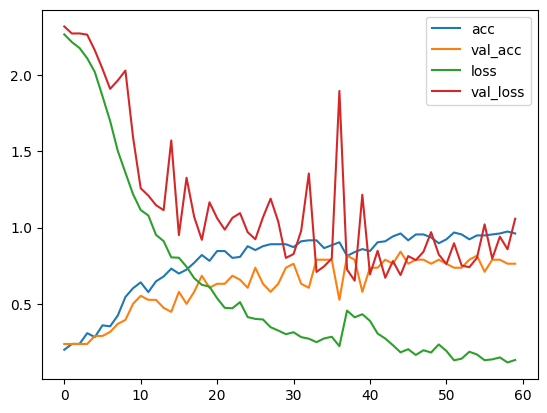

In [43]:
# BLOCK 8 — Trainingskurven plotten
# Zweck: Sichtbar machen, ob Overfitting passiert (val_loss steigt, val_acc stagniert).
# Gut für die Wahl von patience / epochs.

import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


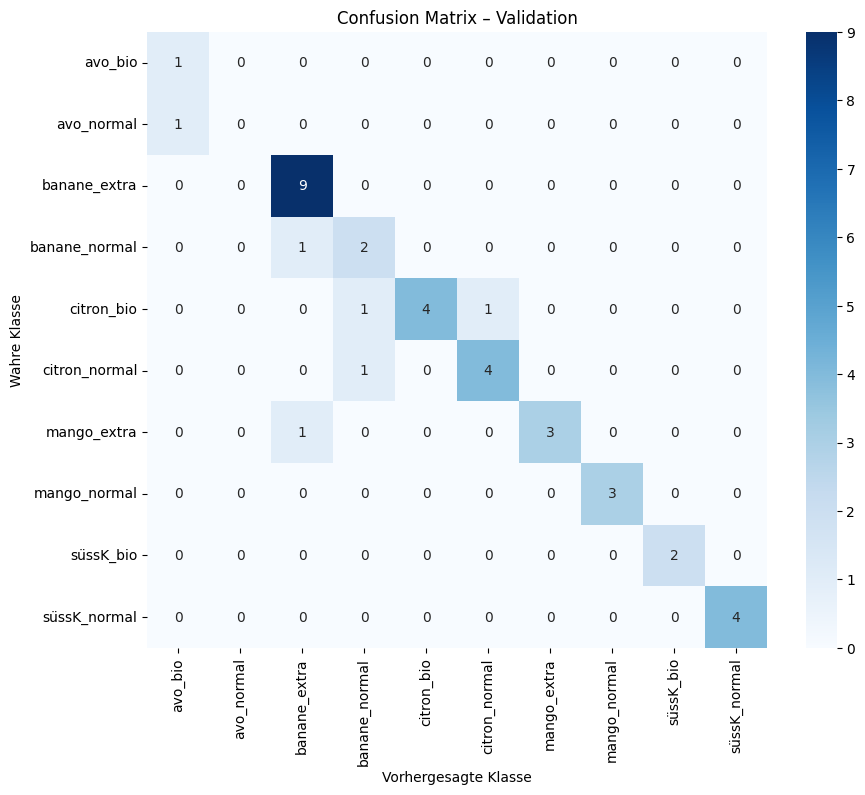


🔍 WICHTIGSTE VERWECHSLUNGEN PRO KLASSE (Validation)
---------------------------------------------------

Klasse: avo_bio
 → Keine Verwechslungen (100 % korrekt im Validation Set)

Klasse: avo_normal
 → wird 1x verwechselt mit: avo_bio
 → Accuracy innerhalb Klasse: 0/1 (0.0%)

Klasse: banane_extra
 → Keine Verwechslungen (100 % korrekt im Validation Set)

Klasse: banane_normal
 → wird 1x verwechselt mit: banane_extra
 → Accuracy innerhalb Klasse: 2/3 (66.7%)

Klasse: citron_bio
 → wird 1x verwechselt mit: banane_normal
 → Accuracy innerhalb Klasse: 4/6 (66.7%)

Klasse: citron_normal
 → wird 1x verwechselt mit: banane_normal
 → Accuracy innerhalb Klasse: 4/5 (80.0%)

Klasse: mango_extra
 → wird 1x verwechselt mit: banane_extra
 → Accuracy innerhalb Klasse: 3/4 (75.0%)

Klasse: mango_normal
 → Keine Verwechslungen (100 % korrekt im Validation Set)

Klasse: süssK_bio
 → Keine Verwechslungen (100 % korrekt im Validation Set)

Klasse: süssK_normal
 → Keine Verwechslungen (100 % korrekt im

In [44]:
# BLOCK 9 — Fehleranalyse auf Validation (Confusion Matrix + Report) — BUGFIX enthalten
# Zweck: Herausfinden, welche Klassen am meisten verwechselt werden.
# BUGFIX: row = cm[i].copy() verhindert, dass die Confusion Matrix zerstört wird.

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for batch_images, batch_labels in val_ds:
    preds = model.predict(batch_images, verbose=0)
    preds_class = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_class)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.title("Confusion Matrix – Validation")
plt.show()

print("\n🔍 WICHTIGSTE VERWECHSLUNGEN PRO KLASSE (Validation)")
print("---------------------------------------------------")

for i, cls in enumerate(class_names):
    row = cm[i].copy()        # <-- BUGFIX
    correct = row[i]
    total = row.sum()

    if total == 0:
        print(f"\n{cls}: Keine Validierungsbilder.")
        continue

    row[i] = -1
    j = np.argmax(row)
    max_confusions = row[j]

    if max_confusions > 0:
        print(f"\nKlasse: {cls}")
        print(f" → wird {max_confusions}x verwechselt mit: {class_names[j]}")
        print(f" → Accuracy innerhalb Klasse: {correct}/{total} ({correct/total:.1%})")
    else:
        print(f"\nKlasse: {cls}")
        print(" → Keine Verwechslungen (100 % korrekt im Validation Set)")

print("\n📊 Klassifikationsreport (Validation):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


In [45]:
# BLOCK 10  Modell speichern (Drive) und wieder laden
# Zweck: Trennung von Training und Evaluation. Speichern ist bewusst überschreibend (neues Modell pro Run).
# Hinweis: Das ist kein "one-time step" — das darf bei jedem Run neu passieren.

import tensorflow as tf

model_save_path = "/content/drive/MyDrive/fruits_model.keras"
model.save(model_save_path)
print("✅ Modell gespeichert nach:", model_save_path)

loaded_model = tf.keras.models.load_model(model_save_path)
print("✅ Modell wieder geladen.")


✅ Modell gespeichert nach: /content/drive/MyDrive/fruits_model.keras
✅ Modell wieder geladen.


Test-Pfad existiert: True
Found 36 files belonging to 10 classes.
Train Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']
Test Klassen : ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.8843 - loss: 0.3153

✅ TEST Accuracy: 88.89%


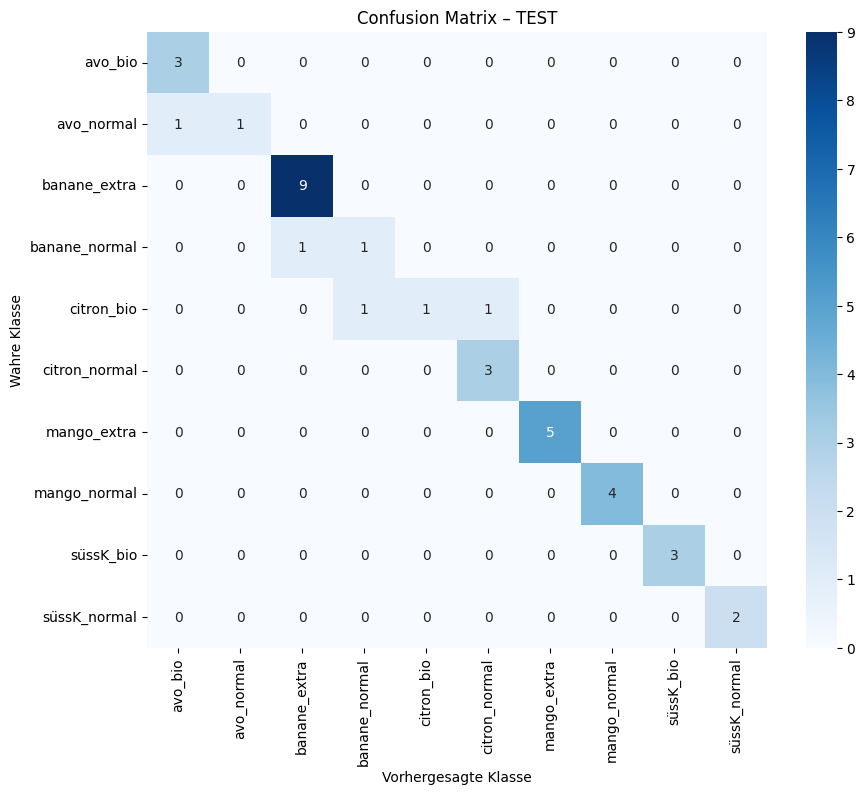


📊 Klassifikationsreport (TEST):
               precision    recall  f1-score   support

      avo_bio       0.75      1.00      0.86         3
   avo_normal       1.00      0.50      0.67         2
 banane_extra       0.90      1.00      0.95         9
banane_normal       0.50      0.50      0.50         2
   citron_bio       1.00      0.33      0.50         3
citron_normal       0.75      1.00      0.86         3
  mango_extra       1.00      1.00      1.00         5
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         3
süssK_normal       1.00      1.00      1.00         2

     accuracy                           0.89        36
    macro avg       0.89      0.83      0.83        36
 weighted avg       0.91      0.89      0.88        36



In [46]:
# BLOCK 11 Evaluation auf echtem Testset (falls vorhanden)
# Zweck: Finaler, ehrlicher Performance-Check auf NIE-benutzten Testdaten.
# Hinweis: Dieser Block verändert keine Daten und ist daher Run-all-sicher.

import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

test_path = "/content/fruits_baum/test"
print("Test-Pfad existiert:", os.path.exists(test_path))

if not os.path.exists(test_path):
    print("⚠️ Kein Testset gefunden. (Optionaler Block 3 wurde evtl. nicht ausgeführt.)")
else:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_path,
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False
    )

    print("Train Klassen:", class_names)
    print("Test Klassen :", test_ds.class_names)

    loss, acc = loaded_model.evaluate(test_ds)
    print(f"\n✅ TEST Accuracy: {acc:.2%}")

    y_true_test = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
    y_pred_prob_test = loaded_model.predict(test_ds, verbose=0)
    y_pred_test = np.argmax(y_pred_prob_test, axis=1)

    cm_test = confusion_matrix(y_true_test, y_pred_test)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Wahre Klasse")
    plt.title("Confusion Matrix – TEST")
    plt.show()

    print("\n📊 Klassifikationsreport (TEST):")
    print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))


In [47]:
# Teilt die Daten in Trainings- (80 %) und Validierungsset (20 %) auf.
# Skaliert Bilder auf 64x64 px und gruppiert sie automatisch nach Klassen.
# Danach werden die Datasets für schnelles Training optimiert (Cache + Prefetch).

import tensorflow as tf

Training_Baumstrukturpfad = "/content/drive/MyDrive/fruits_baum/train"

validation_split = 0.2
image_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    Training_Baumstrukturpfad,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    Training_Baumstrukturpfad,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Klassen:", class_names)

train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 194 files belonging to 10 classes.
Using 156 files for training.
Found 194 files belonging to 10 classes.
Using 38 files for validation.
Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


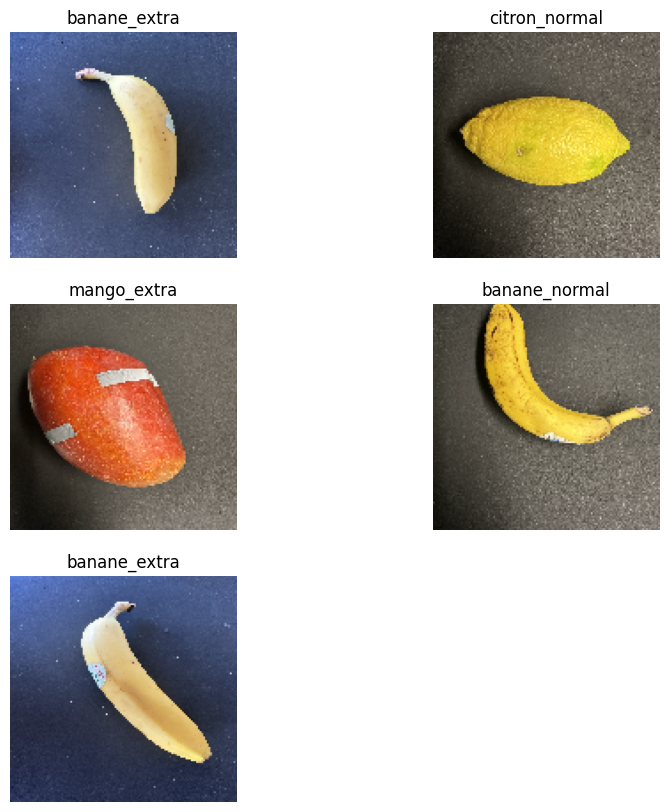

In [48]:
# Zeigt ein paar Trainingsbilder mit Labels, um die Bildqualität (Auflösung) zu prüfen
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Nimmt ein Batch (ca. 32 Bilder)
    for i in range(5):                   # Zeigt 5 davon
        ax = plt.subplot(3, 2, i + 1)
        im = images[i].numpy().astype("uint8")
        plt.imshow(im)
        plt.title(class_names[labels[i]])
        plt.axis("off")


Für die Erkennung der Frucht sollte die Auflösung ausreichen. Lediglich beim der Erkennung kleiner Kleber spezifisch für die Früchte: Zitrone, Süsskartoffel und Banane könnte die geringe Auflösung ein Problem dartstellen. Sollte genau diese Katgeorien (citron_bio; banane_extra und süssK_bio) muss die Auflösung erhöht werden.

**Definieren des Neurnoale Netzwerk**

In [49]:
# Definiert das Convolutional Neural Network (CNN) mit der Functional API.
# Diese Architektur kann später beliebig angepasst oder erweitert werden.

from tensorflow.keras import layers, models
import tensorflow as tf

num_classes = len(class_names)          # Anzahl Zielklassen
color_image_size = (*image_size, 3)     # Eingabegröße inkl. 3 RGB-Kanäle

def make_model():
    # Eingabe-Layer (Größe: 64x64x3)
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    # Normalisierung der Pixelwerte auf [0,1]
    x = layers.Rescaling(1./255)(img_inputs)

    # Datenaugmentation: zufälliges Spiegeln und Drehen
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)

    # 1. Convolutional Block (erkennt einfache Muster)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # 2. Convolutional Block (erkennt komplexere Strukturen)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # 3. Convolutional Block (noch abstraktere Features)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Übergang zu Dense Layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    # Ausgabeschicht: Softmax für Wahrscheinlichkeitsverteilung
    outputs = layers.Dense(num_classes, activation='softmax', name='Ausgabe')(x)

    # Modell definieren
    model = tf.keras.Model(inputs=img_inputs, outputs=outputs, name='FruitClassifier')
    return model

# Modell erstellen und anzeigen
model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_6 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ausgabe (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#  Modell kompilieren – Lernmethode festlegen
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Early Stopping: bricht ab, wenn sich val_accuracy 20 Epochen lang nicht verbessert
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

#  Training starten
epochs = 60          # maximal – Early Stopping beendet früher
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

#  Nach dem Training: Modellleistung ausgeben
loss, acc = model.evaluate(val_ds)
print(f"\n Validation Accuracy: {acc:.2%}")


Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1661 - loss: 2.2794 - val_accuracy: 0.2368 - val_loss: 2.2905
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2221 - loss: 2.1883 - val_accuracy: 0.2368 - val_loss: 2.2790
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2524 - loss: 2.1271 - val_accuracy: 0.2368 - val_loss: 2.3062
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2750 - loss: 1.9873 - val_accuracy: 0.3158 - val_loss: 1.9869
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3621 - loss: 1.7912 - val_accuracy: 0.4211 - val_loss: 1.9018
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4289 - loss: 1.5769 - val_accuracy: 0.3947 - val_loss: 1.8567
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5911 - loss: 1.3384 - val_accuracy: 0.5000 - val_loss: 1.6411
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5410 - loss: 1.1710 - val_accuracy: 0.4211 - val_loss: 1.7296
Epoch 9/60
5/5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


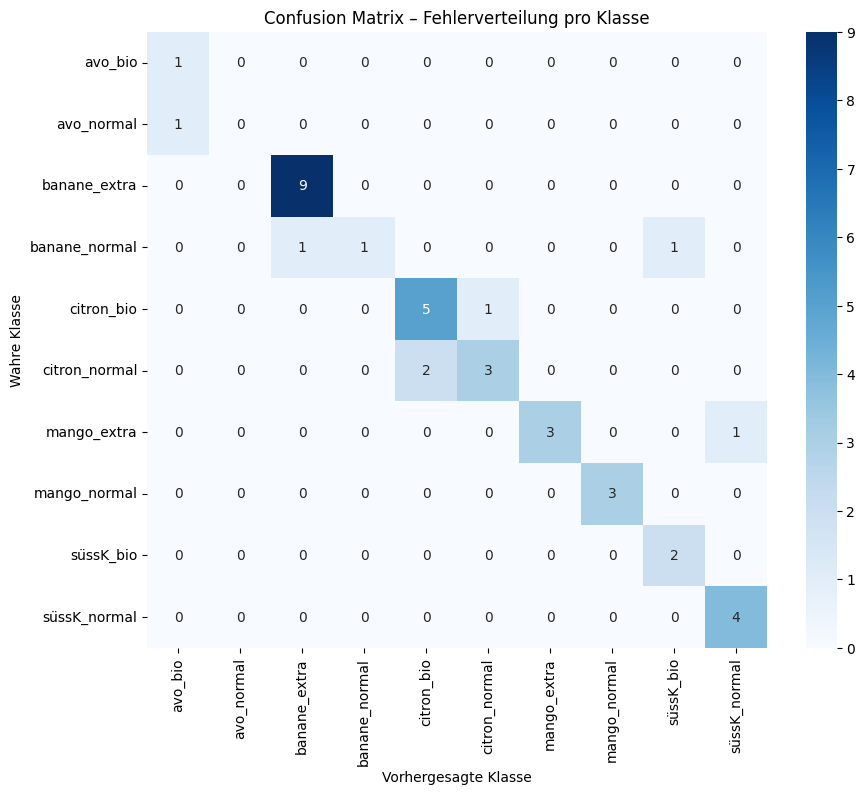



🔍 WICHTIGSTE VERWECHSLUNGEN PRO KLASSE
---------------------------------------

Klasse: avo_bio
 → Keine Verwechslungen  (100 % korrekt im Validation Set)

Klasse: avo_normal
 → wird 1x verwechselt mit: avo_bio
 → Accuracy innerhalb Klasse: 0/1 (0.0%)

Klasse: banane_extra
 → Keine Verwechslungen  (100 % korrekt im Validation Set)

Klasse: banane_normal
 → wird 1x verwechselt mit: banane_extra
 → Accuracy innerhalb Klasse: 1/3 (33.3%)

Klasse: citron_bio
 → wird 1x verwechselt mit: citron_normal
 → Accuracy innerhalb Klasse: 5/6 (83.3%)

Klasse: citron_normal
 → wird 2x verwechselt mit: citron_bio
 → Accuracy innerhalb Klasse: 3/5 (60.0%)

Klasse: mango_extra
 → wird 1x verwechselt mit: süssK_normal
 → Accuracy innerhalb Klasse: 3/4 (75.0%)

Klasse: mango_normal
 → Keine Verwechslungen  (100 % korrekt im Validation Set)

Klasse: süssK_bio
 → Keine Verwechslungen  (100 % korrekt im Validation Set)

Klasse: süssK_normal
 → Keine Verwechslungen  (100 % korrekt im Validation Set)


📊 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
#Eruieren wo die meisten Fehler passieren und dies in die Anpassungen einfliessen lassen
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1) Vorhersagen sammeln
# ---------------------------

y_true = []
y_pred = []

for batch_images, batch_labels in val_ds:
    preds = model.predict(batch_images)
    preds_class = np.argmax(preds, axis=1)

    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_class)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ---------------------------
# 2) Confusion Matrix berechnen
# ---------------------------

cm = confusion_matrix(y_true, y_pred)

# ---------------------------
# 3) Heatmap plotten
# ---------------------------

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.title("Confusion Matrix – Fehlerverteilung pro Klasse")
plt.show()

# ---------------------------
# 4) Verwechslungs-Analyse pro Klasse
# ---------------------------

print("\n\n🔍 WICHTIGSTE VERWECHSLUNGEN PRO KLASSE")
print("---------------------------------------")

for i, cls in enumerate(class_names):
    row = cm[i]
    correct = row[i]
    total = row.sum()

    # keine Bilder dieser Klasse im val-set
    if total == 0:
        print(f"\n{cls}: Keine Validierungsbilder.")
        continue

    # häufigste Verwechslung finden
    row[i] = -1  # eigenen Treffer ignorieren
    j = np.argmax(row)
    max_confusions = row[j]

    if max_confusions > 0:
        print(f"\nKlasse: {cls}")
        print(f" → wird {max_confusions}x verwechselt mit: {class_names[j]}")
        print(f" → Accuracy innerhalb Klasse: {correct}/{total} ({correct/total:.1%})")
    else:
        print(f"\nKlasse: {cls}")
        print(" → Keine Verwechslungen  (100 % korrekt im Validation Set)")

# ---------------------------
# 5) Klassifikationsreport (optional)
# ---------------------------

print("\n\n📊 Klassifikationsreport:")
print(classification_report(y_true, y_pred, target_names=class_names))
